# 00 - Introduction to Vector Databases 

---

This notebook begins my journey into Vector Databases.

Instead of directly learning FAISS or Qdrant, I first want to understand:

- Why Vector Databases were created
- What problem they solve
- How they differ from traditional databases
- Why embeddings are important
- How semantic search works

Understanding these concepts will make learning indexing methods much easier.

##  History

For many years, applications stored information in traditional databases.

Examples:

- MySQL
- PostgreSQL
- SQLite
- MongoDB

These databases are excellent for exact matching.

Example:

Find customer ID = 101

or

Find product name = "Laptop"

However,

AI applications need something different.

Instead of exact matching,

they need **semantic similarity**.

This requirement led to the development of Vector Databases.

##  Think Like a Researcher

Imagine you're building ChatGPT.

A user asks:

"What is Machine Learning?"

Your document says:

"Machine Learning is a branch of Artificial Intelligence."

Notice:

The question and document use different words.

Traditional databases cannot easily understand that they have the same meaning.

Researchers needed a new type of search.

This became Semantic Search.

In [ ]:
documents = [
    "Machine Learning is a branch of Artificial Intelligence.",
    "Python is a programming language.",
    "Transformers use self-attention."
]

query = "Machine Learning"

results = []

for doc in documents:
    if query in doc:
        results.append(doc)

results

#Traditional search only finds exact words.

['Machine Learning is a branch of Artificial Intelligence.']

In [3]:
#problem: If you search for "AI" it will not find the first document because it contains "Artificial Intelligence" instead of "AI".
query = "AI"

results = []

for doc in documents:
    if query in doc:
        results.append(doc)

results

[]

##  Why Traditional Search Fails

Traditional databases compare characters.

AI compares meanings.

Traditional Search

```
AI
```

is different from

```
Artificial Intelligence
```

Humans know they mean the same thing.

Databases don't.

##  Semantic Search

Instead of matching words,

Semantic Search matches meaning.

Example

Query:

```
AI
```

Document:

```
Artificial Intelligence
```

Semantic Search understands that these are closely related.

##  Human Analogy

Suppose your friend asks:

"Where can I buy a car?"

You understand

vehicle

automobile

car

all refer to similar ideas.

Humans naturally understand meaning.

Vector Databases try to do the same using embeddings.

##  Embedding

An embedding converts text into numbers.

Example

```
Cat
```

↓

```
[0.24, -0.81, 0.52, ...]
```

Words with similar meanings produce similar vectors.

In [4]:
word_vectors = {
    "AI":[0.9,0.8],
    "Artificial Intelligence":[0.91,0.82],
    "Football":[-0.8,-0.7]
}

word_vectors

{'AI': [0.9, 0.8],
 'Artificial Intelligence': [0.91, 0.82],
 'Football': [-0.8, -0.7]}

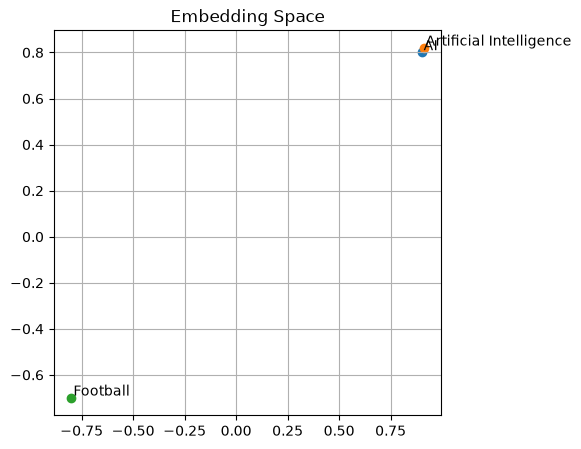

In [ ]:
import matplotlib.pyplot as plt

vectors = {
    "AI":[0.9,0.8],
    "Artificial Intelligence":[0.91,0.82],
    "Football":[-0.8,-0.7]
}

plt.figure(figsize=(5,5))

for word, vector in vectors.items():
    plt.scatter(vector[0], vector[1])
    plt.text(vector[0]+0.01, vector[1]+0.01, word)

plt.grid()

plt.title("Embedding Space")

plt.show()
#Similar words are close together.

##  Comparison

| Traditional Database | Vector Database |
|----------------------|-----------------|
| Stores rows | Stores vectors |
| Exact search | Semantic search |
| SQL | Nearest Neighbor Search |
| IDs | Embeddings |
| WHERE | Similarity Search |

##  Why Not Use SQL?

Suppose you have one million embeddings.

You could compare every vector.

But this would be very slow.

Researchers developed

Vector Indexes

to make search much faster.

##  Pipeline

Documents

↓

Embedding Model

↓

Vectors

↓

Vector Database

↓

User Question

↓

Embedding

↓

Similarity Search

↓

Nearest Documents

In [6]:
import numpy as np

doc1 = np.array([0.9,0.8])

doc2 = np.array([0.91,0.82])

doc3 = np.array([-0.8,-0.7])

query = np.array([0.88,0.79])

def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

print(distance(query,doc1))
print(distance(query,doc2))
print(distance(query,doc3))

0.022360679774997918
0.04242640687119281
2.245551157288562


Smaller distance

↓

More similar.

##  Applications

Vector Databases are used in:

- ChatGPT-style applications
- RAG
- PDF Question Answering
- Recommendation Systems
- Image Search
- Audio Search
- Face Recognition
- Enterprise Search

## Popular Vector Databases

- Qdrant
- FAISS
- Pinecone
- Milvus
- Chroma
- Weaviate

Each one stores vectors efficiently and supports fast similarity search.

##  Limitation

Suppose your database stores

100 million vectors.

Should we compare

100 million vectors

for every query?

No.

That would be too slow.

Researchers solved this problem using

Vector Indexes.

##  Summary

Today I learned:

- Why Vector Databases were created.
- Difference between SQL and Vector Databases.
- Semantic Search.
- Embeddings.
- Similarity Search.
- Real-world applications.